## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [2]:
import pandas as pd

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [3]:
df = pd.read_csv("day73_programming.csv",names=["Date","Tag","Post"],header=0)

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [4]:
df.head()
df.tail(50)

,Date,Tag,Post
2935,2026-03-01 00:00:00,java,91
2936,2026-03-01 00:00:00,javascript,90
2937,2026-03-01 00:00:00,perl,4
2938,2026-03-01 00:00:00,php,36
2939,2026-03-01 00:00:00,python,222
2940,2026-03-01 00:00:00,r,55
2941,2026-03-01 00:00:00,ruby,8
2942,2026-03-01 00:00:00,swift,35
2943,2026-04-01 00:00:00,assembly,12
2944,2026-04-01 00:00:00,c,43


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [5]:
df.shape

(2985, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [6]:
df.count()

Date    2985
Tag     2985
Post    2985
dtype: int64

**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [7]:
df[["Tag","Post"]].groupby("Tag").sum()

,Post
Tag,
assembly,45093
c,407864
c#,1621747
c++,813908
delphi,52534
go,74426
java,1914585
javascript,2522067
perl,68284


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [8]:
df[["Tag","Date"]].groupby("Tag").count()


,Date
Tag,
assembly,215
c,215
c#,216
c++,215
delphi,215
go,200
java,215
javascript,215
perl,215


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Tag,Post
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,c,82
3,2008-08-01,c#,503
4,2008-08-01,c++,164


In [10]:
test_df = pd.DataFrame({'Age': ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old', 'Old'],
                        'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'],
                        'Power': [100, 80, 25, None , 99, 75, 5, 30]})
test_df

,Age,Actor,Power
0,Young,Jack,100.0
1,Young,Arnold,80.0
2,Young,Keanu,25.0
3,Young,Sylvester,NaN
4,Old,Jack,99.0
5,Old,Arnold,75.0
6,Old,Keanu,5.0
7,Old,Sylvester,30.0


In [11]:
pivoted_df = test_df.pivot(index="Age", columns="Actor", values="Power")
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75.0,99.0,5.0,30.0
Young,80.0,100.0,25.0,NaN


## Data Manipulation



In [12]:
reshaped_df = df.pivot(index="Date",columns="Tag",values="Post")
reshaped_df

Tag,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
Date,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01,28.0,320.0,1636.0,749.0,104.0,NaN,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,721.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01,16.0,257.0,1727.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01,11.0,57.0,136.0,122.0,17.0,9.0,111.0,83.0,7.0,33.0,260.0,79.0,3.0,66.0
2026-03-01,15.0,62.0,96.0,113.0,5.0,7.0,91.0,90.0,4.0,36.0,222.0,55.0,8.0,35.0
2026-04-01,12.0,43.0,89.0,81.0,4.0,4.0,75.0,86.0,7.0,21.0,166.0,66.0,1.0,29.0


**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [13]:
reshaped_df.shape

(216, 14)

In [14]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='Tag')

In [15]:
reshaped_df.head()

Tag,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
Date,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01,28.0,320.0,1636.0,749.0,104.0,NaN,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,721.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01,16.0,257.0,1727.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN


**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [16]:
reshaped_df.count()

Tag
assembly      215
c             215
c#            216
c++           215
delphi        215
go            200
java          215
javascript    215
perl          215
php           215
python        215
r             213
ruby          215
swift         206
dtype: int64

In [17]:
reshaped_df.fillna(0,inplace=True)

Tag,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
Date,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,82.0,503.0,164.0,13.0,0.0,220.0,160.0,28.0,157.0,119.0,0.0,68.0,0.0
2008-09-01,28.0,320.0,1636.0,749.0,104.0,0.0,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,0.0
2008-10-01,16.0,302.0,1982.0,804.0,112.0,0.0,1142.0,721.0,128.0,603.0,504.0,0.0,245.0,0.0
2008-11-01,16.0,257.0,1727.0,733.0,139.0,0.0,951.0,581.0,97.0,497.0,446.0,1.0,154.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01,11.0,57.0,136.0,122.0,17.0,9.0,111.0,83.0,7.0,33.0,260.0,79.0,3.0,66.0
2026-03-01,15.0,62.0,96.0,113.0,5.0,7.0,91.0,90.0,4.0,36.0,222.0,55.0,8.0,35.0
2026-04-01,12.0,43.0,89.0,81.0,4.0,4.0,75.0,86.0,7.0,21.0,166.0,66.0,1.0,29.0


In [18]:
reshaped_df.count()

Tag
assembly      216
c             216
c#            216
c++           216
delphi        216
go            216
java          216
javascript    216
perl          216
php           216
python        216
r             216
ruby          216
swift         216
dtype: int64

In [24]:
reshaped_df.isna().values.any()


np.False_

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

In [19]:
import matplotlib.pyplot as plt

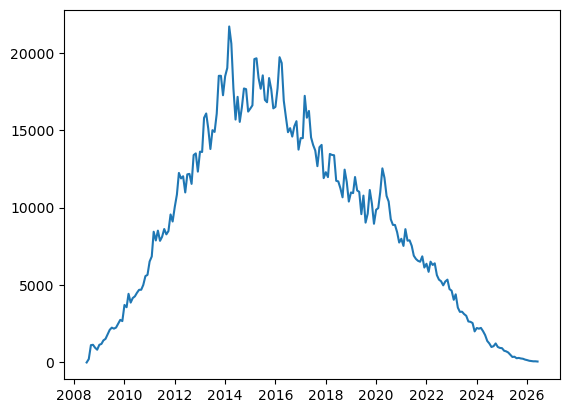

In [29]:
plt.plot(reshaped_df.index,reshaped_df.java)
# plt.plot(reshaped_df["java"])

In [23]:
reshaped_df["java"]

Date
2008-07-01       0.0
2008-08-01     220.0
2008-09-01    1119.0
2008-10-01    1142.0
2008-11-01     951.0
               ...  
2026-02-01     111.0
2026-03-01      91.0
2026-04-01      75.0
2026-05-01      76.0
2026-06-01      62.0
Name: java, Length: 216, dtype: float64

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

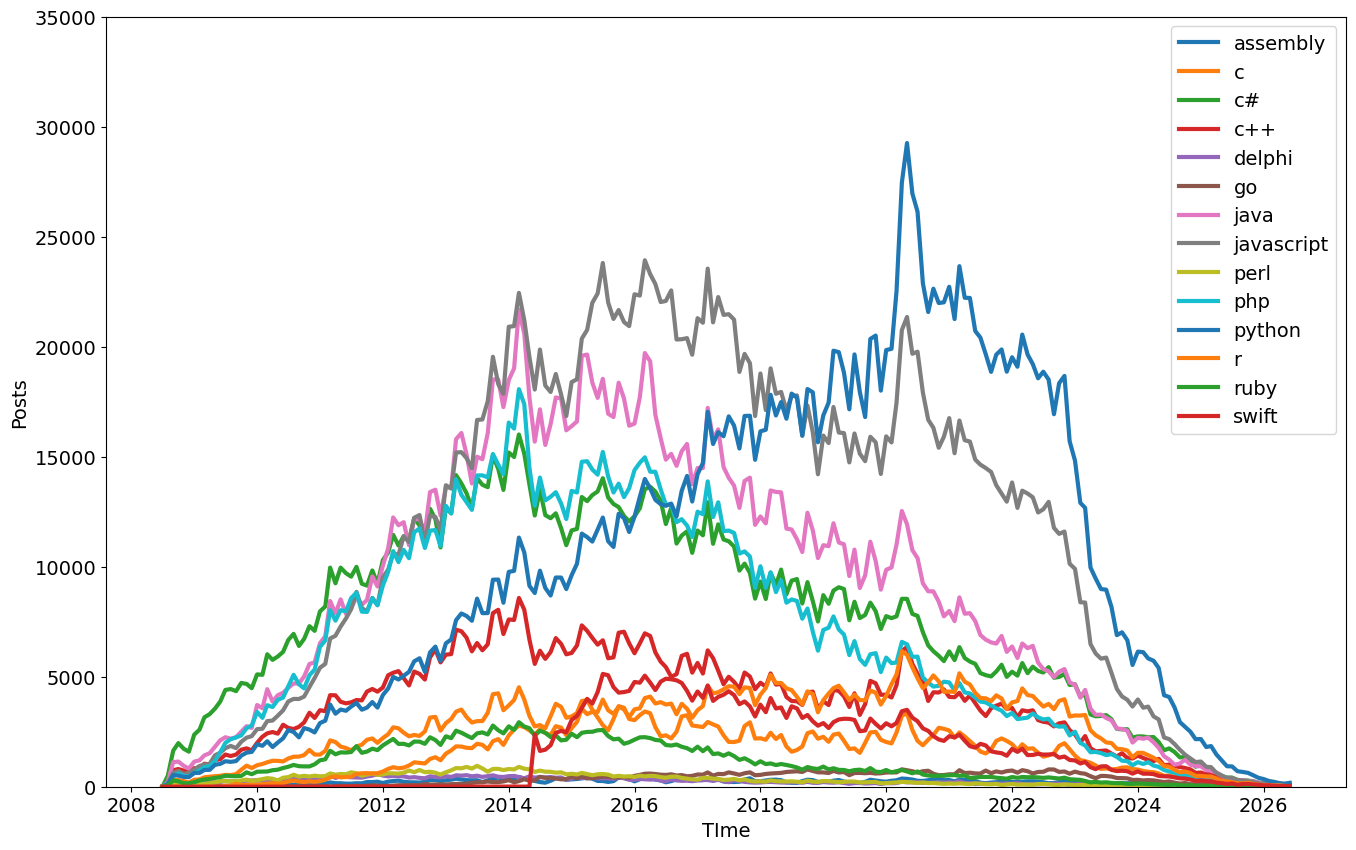

In [44]:
# Main styles are figure(for size), xticks,yticks,xlable,ylabel and xlim,ylim
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,35000)
plt.xlabel("TIme",fontsize=14)
plt.ylabel("Posts",fontsize=14)
for cols in reshaped_df.columns:
    plt.plot(reshaped_df[cols],linewidth=3,label=cols)
plt.legend(fontsize=14)

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

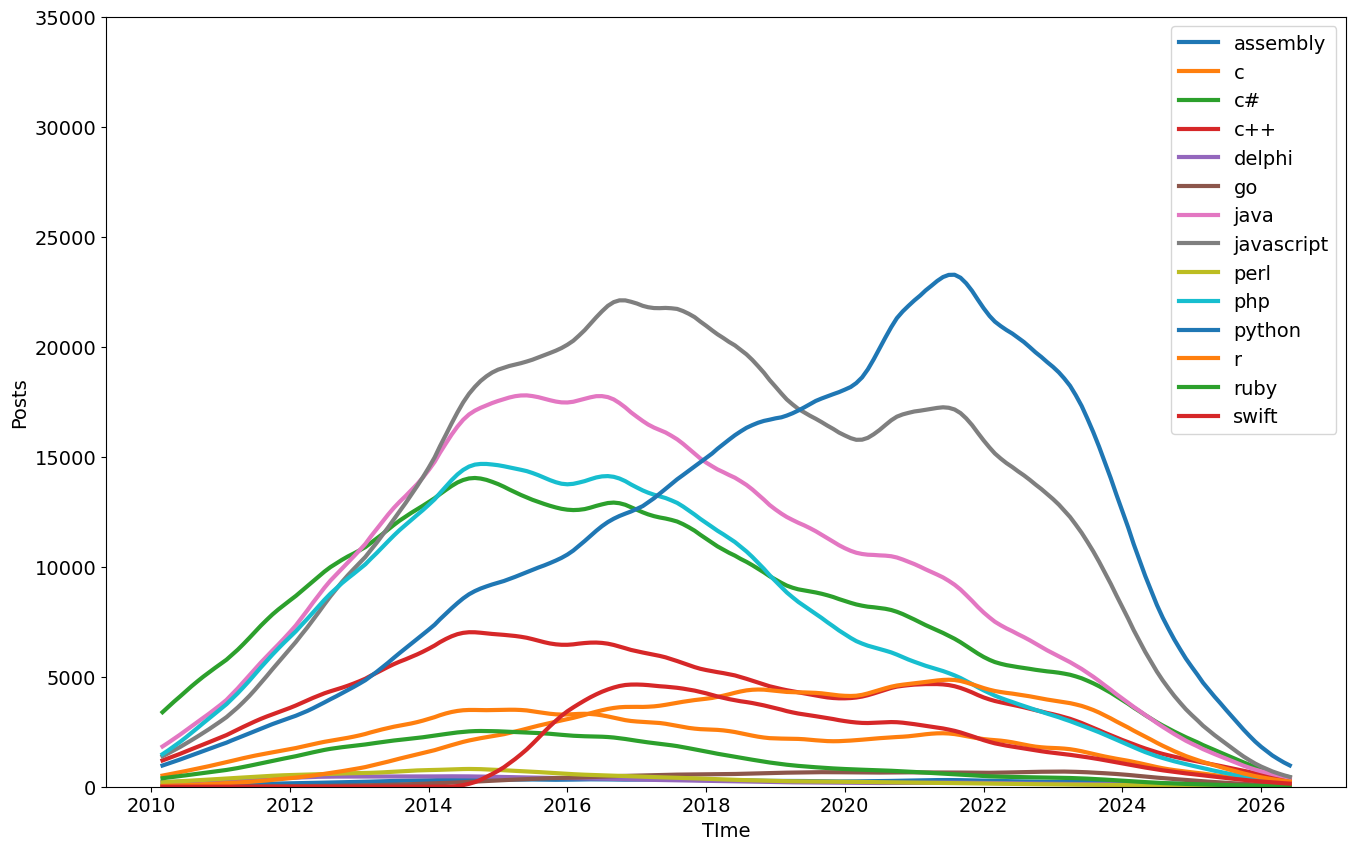

In [46]:
# rolling
reshaped_df = reshaped_df.rolling(window=16).mean()
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,35000)
plt.xlabel("TIme",fontsize=14)
plt.ylabel("Posts",fontsize=14)
for cols in reshaped_df.columns:
    plt.plot(reshaped_df[cols],linewidth=3,label=cols)
plt.legend(fontsize=14)